# Exploratory Data Analysis

Loading and exploring the `MINDsmall_train` split (news metadata + user behavior logs).

## Setup
Import common libraries and verify that the dataset files are present.

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')

In [4]:
DATA_DIR = Path('smallDataset') / 'MINDsmall_train'
BEHAVIORS_PATH = DATA_DIR / 'behaviors.tsv'
NEWS_PATH = DATA_DIR / 'news.tsv'

if not BEHAVIORS_PATH.exists():
    raise FileNotFoundError(f'Missing behaviors file: {BEHAVIORS_PATH}')
if not NEWS_PATH.exists():
    raise FileNotFoundError(f'Missing news file: {NEWS_PATH}')

print(f'Data directory: {DATA_DIR.resolve()}')
print(f'Behaviors size: {BEHAVIORS_PATH.stat().st_size / 1e6:.1f} MB')
print(f'News size: {NEWS_PATH.stat().st_size / 1e6:.1f} MB')

Data directory: /home/asmvas/Documents/NTNU-prosjekt/anbefalingssytem/AnbSysProsjekt/smallDataset/MINDsmall_train
Behaviors size: 92.0 MB
News size: 41.2 MB


In [5]:
behavior_columns = ['impression_id', 'user_id', 'time', 'history', 'impressions']
news_columns = [
    'news_id', 'category', 'subcategory', 'title', 'abstract', 'url', 'title_entities', 'abstract_entities'
]

behaviors_df = pd.read_csv(
    BEHAVIORS_PATH,
    sep='	',
    names=behavior_columns,
    parse_dates=['time'],
    keep_default_na=False,
    na_values=['', 'null', 'None']
)

news_df = pd.read_csv(
    NEWS_PATH,
    sep='	',
    names=news_columns,
    keep_default_na=False,
    na_values=['', 'null', 'None']
)

print(f'Behaviors shape: {behaviors_df.shape}')
print(f'News shape: {news_df.shape}')

Behaviors shape: (156965, 5)
News shape: (51282, 8)


## First look at the raw tables

In [6]:
display(behaviors_df.head())
display(news_df[['news_id', 'category', 'subcategory', 'title']].head())

,impression_id,user_id,time,history,impressions
0,1,U13740,2019-11-11 09:05:58,N55189 N42782 N34694 N45794 N18445 N63302 N10414 N19347 N31801,N55689-1 N35729-0
1,2,U91836,2019-11-12 18:11:30,N31739 N6072 N63045 N23979 N35656 N43353 N8129 N1569 N17686 N13008 N21623 N6233 N14340 N48031 N62285 N44383 N23061 N...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N22407-0 N14592-0 N17059-1 N33677-0 N7821-0 N6890-0
2,3,U73700,2019-11-14 07:01:48,N10732 N25792 N7563 N21087 N41087 N5445 N60384 N46616 N52500 N33164 N47289 N24233 N62058 N26378 N49475 N18870,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N59685-0 N23814-1 N23446-0 N64174-0 N11817-0 N60550-0 N48225-0 N45509-0...
3,4,U34670,2019-11-11 05:28:05,N45729 N2203 N871 N53880 N41375 N43142 N33013 N29757 N31825 N51891,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,2019-11-12 16:11:21,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N60408-0 N61497-0 N47412-0 N41220-0 N1940-0 N724-0 N11363-0 N261-0 N3388...


,news_id,category,subcategory,title
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, and Prince Philip Swear By"
1,N19639,health,weightloss,50 Worst Habits For Belly Fat
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches of Ukraine's War
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My Mental Health.
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a Dermatologist"


## High-level overview

In [7]:
time_min = behaviors_df['time'].min()
time_max = behaviors_df['time'].max()
time_range = f"{time_min.strftime('%Y-%m-%d %H:%M')} → {time_max.strftime('%Y-%m-%d %H:%M')}"

dataset_overview = pd.DataFrame(
    {
        'rows': [len(behaviors_df), len(news_df)],
        'unique_ids': [behaviors_df['user_id'].nunique(), news_df['news_id'].nunique()],
        'time_range': [time_range, 'N/A'],
        'notes': ['User impression logs', 'News metadata entries']
    },
    index=['behaviors', 'news']
)

display(dataset_overview)

,rows,unique_ids,time_range,notes
behaviors,156965,50000,2019-11-09 00:00 → 2019-11-14 23:59,User impression logs
news,51282,51282,N/A,News metadata entries


## Behavior-level signals

In [8]:
history_series = behaviors_df['history'].fillna('')
behaviors_df['history_len'] = history_series.apply(lambda x: 0 if x == '' else len(x.split()))

impressions_series = behaviors_df['impressions'].fillna('')
behaviors_df['impression_count'] = impressions_series.apply(lambda x: 0 if x == '' else len(x.split()))
behaviors_df['clicked_count'] = impressions_series.str.count('-1').astype('int32')
behaviors_df['not_clicked_count'] = (behaviors_df['impression_count'] - behaviors_df['clicked_count']).astype('int32')
behaviors_df['click_through_rate'] = np.where(
    behaviors_df['impression_count'] > 0,
    behaviors_df['clicked_count'] / behaviors_df['impression_count'],
    np.nan
)

total_impressions = behaviors_df['impression_count'].sum()
total_clicks = behaviors_df['clicked_count'].sum()
overall_ctr = total_clicks / total_impressions

print(f'Total impressions: {total_impressions:,}')
print(f'Total clicks: {total_clicks:,}')
print(f'Overall CTR: {overall_ctr:.3%}')

behavior_summary = behaviors_df[['history_len', 'impression_count', 'clicked_count', 'click_through_rate']].describe().T
behavior_summary['mean'] = behavior_summary['mean'].round(2)
behavior_summary['std'] = behavior_summary['std'].round(2)

display(behavior_summary)

Total impressions: 5,843,444
Total clicks: 236,344
Overall CTR: 4.045%


,count,mean,std,min,25%,50%,75%,max
history_len,156965.0,32.54,40.27,0.000000,8.000000,19.000000,42.000,558.00
impression_count,156965.0,37.23,38.59,2.000000,10.000000,24.000000,51.000,299.00
clicked_count,156965.0,1.51,1.15,1.000000,1.000000,1.000000,2.000,35.00
click_through_rate,156965.0,0.11,0.13,0.003367,0.028571,0.055556,0.125,0.75


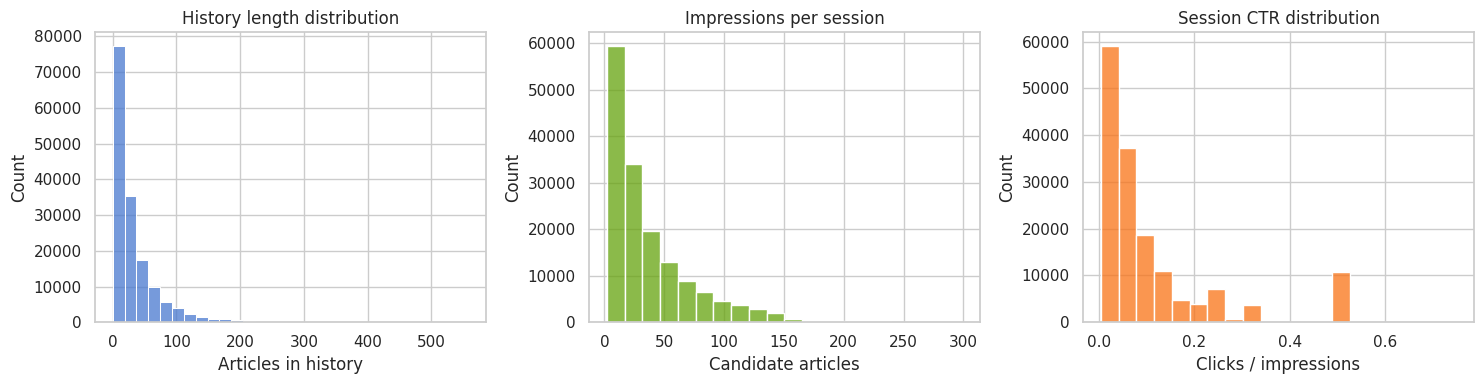

In [9]:
plot_sample = behaviors_df.sample(n=min(200000, len(behaviors_df)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(plot_sample['history_len'], bins=30, ax=axes[0], color='#4878CF')
axes[0].set_title('History length distribution')
axes[0].set_xlabel('Articles in history')

sns.histplot(plot_sample['impression_count'], bins=20, ax=axes[1], color='#65A30D')
axes[1].set_title('Impressions per session')
axes[1].set_xlabel('Candidate articles')

sns.histplot(plot_sample['click_through_rate'].dropna(), bins=20, ax=axes[2], color='#F97316')
axes[2].set_title('Session CTR distribution')
axes[2].set_xlabel('Clicks / impressions')

plt.tight_layout()
plt.show()

## News-level signals

,count,mean,std,min,25%,50%,75%,max
title_length,51282.0,10.75,3.27,1.0,9.0,10.0,13.0,57.0
abstract_length,51282.0,34.29,26.54,0.0,15.0,24.0,62.0,474.0


,articles
category,
news,15774
sports,14510
finance,3107
foodanddrink,2551
lifestyle,2479
travel,2350
video,2068
weather,2048
health,1885


,articles
subcategory,
newsus,6564
football_nfl,5420
newspolitics,2826
newscrime,2254
weathertopstories,2047
newsworld,1720
football_ncaa,1665
baseball_mlb,1661
basketball_nba,1555


/tmp/ipykernel_31617/3972307615.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, ax=axes[0], palette='crest')
/tmp/ipykernel_31617/3972307615.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_subcategories.values, y=top_subcategories.index, ax=axes[1], palette='mako')


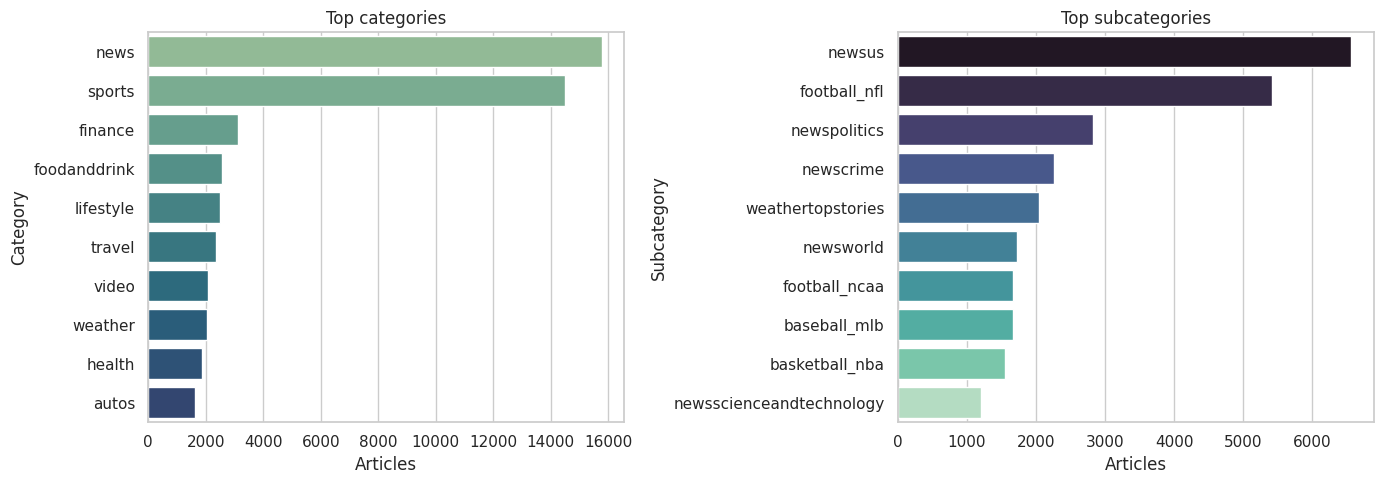

In [10]:
news_df['title_length'] = news_df['title'].fillna('').apply(lambda x: len(x.split()))
news_df['abstract_length'] = news_df['abstract'].fillna('').apply(lambda x: len(x.split()))

news_summary = news_df[['title_length', 'abstract_length']].describe().T.round(2)

top_categories = news_df['category'].value_counts().head(10)
top_subcategories = news_df['subcategory'].value_counts().head(10)

display(news_summary)
display(top_categories.to_frame('articles'))
display(top_subcategories.to_frame('articles'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=top_categories.values, y=top_categories.index, ax=axes[0], palette='crest')
axes[0].set_title('Top categories')
axes[0].set_xlabel('Articles')
axes[0].set_ylabel('Category')

sns.barplot(x=top_subcategories.values, y=top_subcategories.index, ax=axes[1], palette='mako')
axes[1].set_title('Top subcategories')
axes[1].set_xlabel('Articles')
axes[1].set_ylabel('Subcategory')

plt.tight_layout()
plt.show()